## __Notebook de conception des méthodes de préprocessing__

## Importations

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import torch

## Analyse des données disponibles

In [12]:
import os
import numpy as np
from PIL import Image

folder_path = "data/train/"
widths, heights = [], []

# Initialisation pour les stats de pixels (RGB)
sum_pixels = np.zeros(3)    # Somme des [R, G, B]
sum_sq_pixels = np.zeros(3) # Somme des [R², G², B²]
total_pixel_count = 0

valid_exts = (".jpg", ".png", ".jpeg")

for path in os.listdir(folder_path):
    sub_path = os.path.join(folder_path, path)
    if os.path.isdir(sub_path):
        for filename in os.listdir(sub_path):
            if filename.lower().endswith(valid_exts):
                img_path = os.path.join(sub_path, filename)
                
                with Image.open(img_path).convert('RGB') as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
                    
                    img_array = np.array(img) / 255.0
                    
                    # On "aplatit" l'image pour avoir une liste de pixels (N, 3)
                    pixels = img_array.reshape(-1, 3)
                    
                    sum_pixels += pixels.sum(axis=0)
                    sum_sq_pixels += (pixels**2).sum(axis=0)
                    total_pixel_count += pixels.shape[0]

# Calculs finaux
mean = sum_pixels / total_pixel_count
# Formule de la variance : E[X²] - (E[X])²
std = np.sqrt((sum_sq_pixels / total_pixel_count) - (mean**2))

print(f"--- Dimensions ---")
print(f"Min: {min(widths)}x{min(heights)} | Max: {max(widths)}x{max(heights)}")
print(f"Moyenne: {np.mean(widths):.1f}x{np.mean(heights):.1f}")

print(f"\n--- Statistiques Colorimétriques (pour PyTorch) ---")
print(f"Moyenne (RGB): {mean}")
print(f"Std     (RGB): {std}")

--- Dimensions ---
Min: 48x34 | Max: 2880x2048
Moyenne: 431.2x401.9

--- Statistiques Colorimétriques (pour PyTorch) ---
Moyenne (RGB): [0.54151865 0.50277623 0.33710416]
Std     (RGB): [0.25970188 0.24740465 0.26307435]


In [ ]:
class Preprocessor:
    def __init__(self, normalize=True, resize_method="crop", target_size=(224, 224)):
        self.mean = np.array([0.54151865, 0.50277623, 0.33710416])    
        self.std = np.array([0.25970188, 0.24740465, 0.26307435])
        self.normalize_flag = normalize
        self.resize_method = resize_method
        self.target_size = target_size
    
    def normalize(self, img_array):
        return (img_array - self.mean) / self.std
    
    def resize_img(self, img, method, target_size=(224, 224)):
        tw, th = target_size
        
        if method == "resize":
            # Déformation directe
            return img.resize(target_size, Image.Resampling.LANCZOS)
        
        elif method == "crop":
            # Logique : Redimensionner le PETIT côté pour qu'il touche le bord du cadre, puis couper l'excès
            return ImageOps.fit(img, target_size, Image.Resampling.LANCZOS)
            
        elif method == "pad":
            # Logique : Redimensionner le GRAND côté pour qu'il rentre dans le cadre, puis ajouter du blanc
            img.thumbnail(target_size, Image.Resampling.LANCZOS)
            
            new_img = Image.new("RGB", target_size, (255, 255, 255))
            
            offset = ((tw - img.size[0]) // 2, (th - img.size[1]) // 2)
            new_img.paste(img, offset)
            return new_img
    
    def __call__(self, img):
        img_resized = self.resize_img(img, method=self.resize_method, target_size=self.target_size)
        
        img_array = np.array(img_resized).astype(np.float32) / 255.0

        if self.normalize_flag:
            img_array = self.normalize(img_array)
        
        img_tensor = img_array.transpose(2, 0, 1) # Convertir de (H, W, C) à (C, H, W) pour torch
        return img_tensor

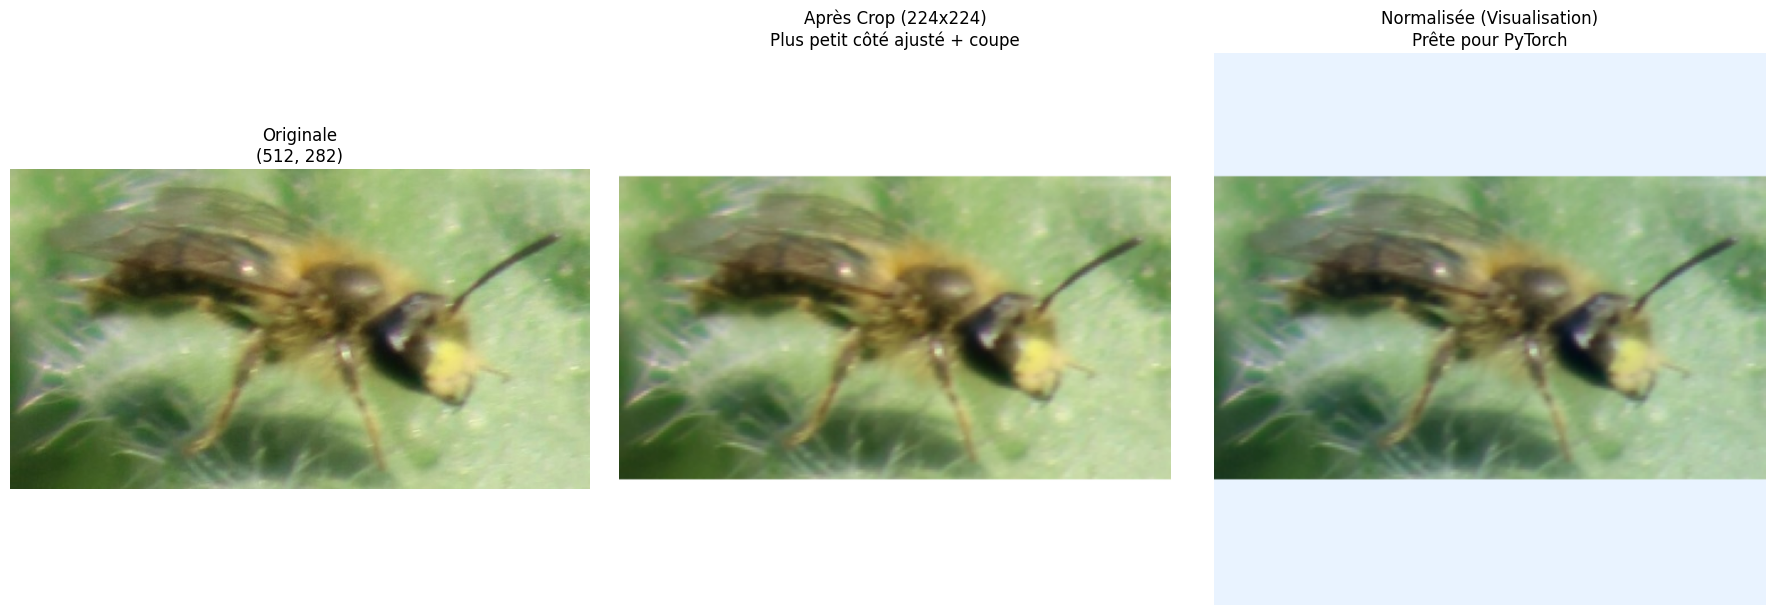

Shape finale: (224, 224, 3)
Valeur moyenne après normalisation: 1.2657 (proche de 0)


In [ ]:
image = "/home/alexandre-tonon/SDD/Hackathons/Hackaton_abeilles_tigres/data/train/Andrena aerinifrons/0dd958b3b7431b1da1cdcffb7f310bf188f421c0.jpg"
preprocessor = Preprocessor(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

with Image.open(image).convert('RGB') as img:
    axes[0].imshow(img)
    axes[0].set_title(f"Originale\n{img.size}")
    
    resized_img = preprocessor.resize_img(img, method="pad", target_size=(224, 224))
    axes[1].imshow(resized_img)
    axes[1].set_title("Après Resize")
    
    img_array = np.array(resized_img) / 255.0
    normalized_array = preprocessor.normalize(img_array)
    
    display_norm = (normalized_array - normalized_array.min()) / (normalized_array.max() - normalized_array.min())
    axes[2].imshow(display_norm)
    axes[2].set_title("Normalisée (Visualisation)\nPrête pour PyTorch")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# 4. Vérification des données pour Torch
print(f"Shape finale: {normalized_array.shape}")
print(f"Valeur moyenne après normalisation: {normalized_array.mean():.4f} (proche de 0)")

